# Experiment 5.4.3 — Causal elapsed-time readout capacity

**Analysis-only notebook.** Training, selection, and final-test execution live in the Python/Slurm pipeline. This notebook only reads finalized CSV/JSON artifacts and never regenerates missing runs.

Question: can a compact causal elapsed-time-conditioned readout recover the phase-specific weighting of frozen-WHAT Fixed250 + full Linear?


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('notebooks/artifacts/experiment_5_4_3_elapsed_readout_capacity/elapsed_readout_capacity_v1')
if not ROOT.exists():
    ROOT = Path('artifacts/experiment_5_4_3_elapsed_readout_capacity/elapsed_readout_capacity_v1')
ROOT


PosixPath('artifacts/experiment_5_4_3_elapsed_readout_capacity/elapsed_readout_capacity_v1')

In [2]:
required = ['reference_runs.csv', 'capacity_runs.csv', 'capacity_summary.csv', 'capacity_recovery.csv', 'capacity_selection.json']
missing = [name for name in required if not (ROOT / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing finalized Stage-A artifacts: {missing}')
reference = pd.read_csv(ROOT / 'reference_runs.csv')
capacity = pd.read_csv(ROOT / 'capacity_runs.csv')
capacity_summary = pd.read_csv(ROOT / 'capacity_summary.csv')
recovery = pd.read_csv(ROOT / 'capacity_recovery.csv')
capacity_selection = json.loads((ROOT / 'capacity_selection.json').read_text())

summary_parts = [capacity_summary.assign(source_stage='capacity')]
if (ROOT / 'extension_summary.csv').exists():
    extension_summary = pd.read_csv(ROOT / 'extension_summary.csv')
    summary_parts.append(extension_summary.assign(source_stage='extension'))
summary = pd.concat(summary_parts, ignore_index=True, sort=False)
selection = json.loads((ROOT / 'selection.json').read_text()) if (ROOT / 'selection.json').exists() else None

display(reference)
display(summary.sort_values('mean_val_balanced_accuracy', ascending=False))
print('Stage-A decision:')
display(capacity_selection)
if selection is not None:
    print('Locked validation-only selection:')
    display(selection)


,seed,base_val_balanced_accuracy,fixed250_val_balanced_accuracy,fixed250_train_balanced_accuracy,fixed250_gap_over_base,offline_streaming_max_abs_logit_delta,test_evaluated
0,11,0.520280,0.525289,0.996546,0.005008,1.065814e-14,False
1,23,0.513005,0.611562,0.996546,0.098557,3.197442e-14,False
2,37,0.490651,0.545743,0.996546,0.055093,1.243450e-14,False
3,53,0.471765,0.511165,0.996546,0.039400,1.421085e-14,False
4,71,0.513336,0.542971,0.991675,0.029636,1.421085e-14,False


,stage,parameterization,n_banks,rank,mean_val_balanced_accuracy,mean_paired_val_delta_vs_base,sem_paired_val_delta_vs_base,nonnegative_seed_count,mean_oracle_gap_recovery_fraction,mean_gap_to_fixed250_val_ba,trainable_parameter_count,eligible,strong_recovery,source_stage
7,capacity,factorized,16,8,0.561667,0.059859,0.007468,5,3.685497,-0.014321,18945,True,True,capacity
4,capacity,factorized,8,8,0.559413,0.057606,0.012250,5,3.975676,-0.012067,9473,True,True,capacity
8,capacity,factorized,16,12,0.559168,0.057361,0.007300,5,3.587609,-0.011822,27905,True,True,capacity
5,capacity,factorized,8,12,0.558123,0.056316,0.005963,5,3.064554,-0.010777,13953,True,True,capacity
6,capacity,factorized,16,4,0.553194,0.051386,0.006111,5,3.009555,-0.005848,9985,True,True,capacity
1,capacity,factorized,4,8,0.549462,0.047655,0.013590,5,2.313211,-0.002116,4737,True,True,capacity
2,capacity,factorized,4,12,0.546282,0.044475,0.008543,5,2.667255,0.001064,6977,True,True,capacity
0,capacity,factorized,4,4,0.534422,0.032614,0.008696,5,1.442721,0.012924,2497,True,False,capacity
3,capacity,factorized,8,4,0.530203,0.028396,0.006154,5,0.778487,0.017143,4993,True,False,capacity


Stage-A decision:


{'capacity_summary': [{'eligible': True,
   'mean_gap_to_fixed250_val_ba': 0.012924482924482927,
   'mean_oracle_gap_recovery_fraction': 1.4427211696548201,
   'mean_paired_val_delta_vs_base': 0.03261423761423758,
   'mean_val_balanced_accuracy': 0.5344215969215969,
   'n_banks': 4,
   'nonnegative_seed_count': 5,
   'parameterization': 'factorized',
   'rank': 4,
   'sem_paired_val_delta_vs_base': 0.008696188149132198,
   'stage': 'capacity',
   'strong_recovery': False,
   'trainable_parameter_count': 2497},
  {'eligible': True,
   'mean_gap_to_fixed250_val_ba': -0.0021164021164021053,
   'mean_oracle_gap_recovery_fraction': 2.3132114486400783,
   'mean_paired_val_delta_vs_base': 0.04765512265512262,
   'mean_val_balanced_accuracy': 0.5494624819624819,
   'n_banks': 4,
   'nonnegative_seed_count': 5,
   'parameterization': 'factorized',
   'rank': 8,
   'sem_paired_val_delta_vs_base': 0.013589588137310137,
   'stage': 'capacity',
   'strong_recovery': True,
   'trainable_parameter_co

Locked validation-only selection:


{'capacity_selection': {'capacity_summary': [{'eligible': True,
    'mean_gap_to_fixed250_val_ba': 0.012924482924482927,
    'mean_oracle_gap_recovery_fraction': 1.4427211696548201,
    'mean_paired_val_delta_vs_base': 0.03261423761423758,
    'mean_val_balanced_accuracy': 0.5344215969215969,
    'n_banks': 4,
    'nonnegative_seed_count': 5,
    'parameterization': 'factorized',
    'rank': 4,
    'sem_paired_val_delta_vs_base': 0.008696188149132198,
    'stage': 'capacity',
    'strong_recovery': False,
    'trainable_parameter_count': 2497},
   {'eligible': True,
    'mean_gap_to_fixed250_val_ba': -0.0021164021164021053,
    'mean_oracle_gap_recovery_fraction': 2.3132114486400783,
    'mean_paired_val_delta_vs_base': 0.04765512265512262,
    'mean_val_balanced_accuracy': 0.5494624819624819,
    'n_banks': 4,
    'nonnegative_seed_count': 5,
    'parameterization': 'factorized',
    'rank': 8,
    'sem_paired_val_delta_vs_base': 0.013589588137310137,
    'stage': 'capacity',
    'str

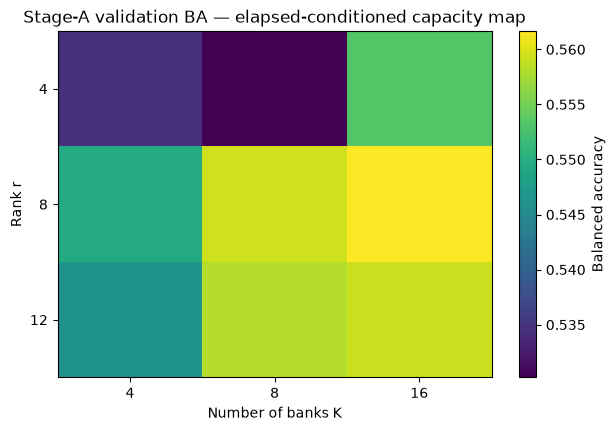

In [3]:
pivot = capacity_summary[capacity_summary.parameterization == 'factorized'].pivot(index='rank', columns='n_banks', values='mean_val_balanced_accuracy')
fig, ax = plt.subplots(figsize=(7, 4.5))
image = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)), [str(v) for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [str(v) for v in pivot.index])
ax.set_xlabel('Number of banks K')
ax.set_ylabel('Rank r')
ax.set_title('Stage-A validation BA — elapsed-conditioned capacity map')
fig.colorbar(image, ax=ax, label='Balanced accuracy')
plt.show()


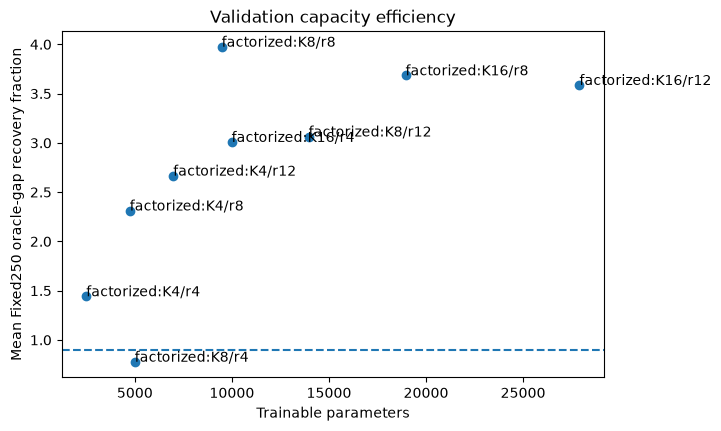

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ordered = summary.sort_values('trainable_parameter_count')
ax.scatter(ordered.trainable_parameter_count, ordered.mean_oracle_gap_recovery_fraction)
for _, row in ordered.iterrows():
    label = f"{row.parameterization}:K{int(row.n_banks)}/r{int(row['rank'])}"
    ax.annotate(label, (row.trainable_parameter_count, row.mean_oracle_gap_recovery_fraction))
ax.axhline(0.90, linestyle='--')
ax.set_xlabel('Trainable parameters')
ax.set_ylabel('Mean Fixed250 oracle-gap recovery fraction')
ax.set_title('Validation capacity efficiency')
plt.show()


,seed,selected_stage,parameterization,n_banks,rank,trainable_parameter_count,base_test_balanced_accuracy,fixed250_test_balanced_accuracy,anchor_k4_r4_test_balanced_accuracy,selected_test_balanced_accuracy,selected_delta_test_ba_vs_base,selected_gap_to_fixed250_test_ba,oracle_gap_recovery_fraction,selected_test_accuracy,selected_test_macro_f1,selected_test_loss,fixed250_streaming_max_abs_logit_delta
0,11,capacity,factorized,4,8,4737,0.446069,0.609449,0.491528,0.452244,0.006176,0.157205,0.037800,0.458904,0.436896,3.761062,1.421085e-14
1,23,capacity,factorized,4,8,4737,0.491524,0.593132,0.524879,0.526690,0.035166,0.066442,0.346097,0.534247,0.522212,3.807053,1.065814e-14
2,37,capacity,factorized,4,8,4737,0.482243,0.587313,0.490365,0.588070,0.105827,-0.000758,1.007210,0.595890,0.576412,2.914971,1.065814e-14
3,53,capacity,factorized,4,8,4737,0.498640,0.585777,0.534067,0.502894,0.004255,0.082882,0.048828,0.513699,0.476347,3.924673,1.065814e-14
4,71,capacity,factorized,4,8,4737,0.438638,0.600482,0.464257,0.441927,0.003289,0.158555,0.020322,0.452055,0.437861,3.416857,1.243450e-14


,base_test_balanced_accuracy,fixed250_test_balanced_accuracy,anchor_k4_r4_test_balanced_accuracy,selected_test_balanced_accuracy,oracle_gap_recovery_fraction
mean,0.471423,0.595230,0.501019,0.502365,0.292052
std,0.027293,0.009826,0.028357,0.059376,0.421904


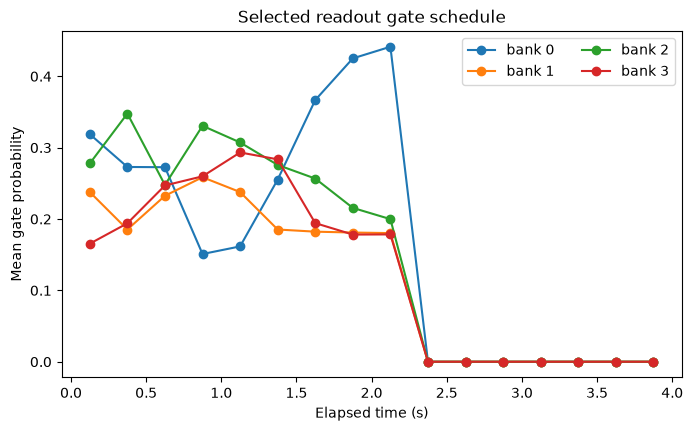

,normalized_frobenius_distance,cosine_similarity
bin_index,,
0,1.910671e+00,0.104732
1,3.253044e+00,0.179105
2,4.094155e+00,0.249628
3,3.981624e+00,0.340787
4,3.130183e+00,0.316456
5,3.361227e+00,0.176223
6,3.365749e+00,0.138190
7,2.573161e+00,0.080036
8,2.732967e+00,0.092615


In [5]:
if (ROOT / 'final_runs.csv').exists():
    final = pd.read_csv(ROOT / 'final_runs.csv')
    display(final)
    cols = ['base_test_balanced_accuracy', 'fixed250_test_balanced_accuracy', 'anchor_k4_r4_test_balanced_accuracy', 'selected_test_balanced_accuracy', 'oracle_gap_recovery_fraction']
    display(final[cols].agg(['mean', 'std']))

    if (ROOT / 'gate_activity.csv').exists():
        gate = pd.read_csv(ROOT / 'gate_activity.csv')
        gate_time = gate[gate.metric == 'bank_probability_by_elapsed_time']
        if len(gate_time):
            gate_mean = gate_time.groupby(['elapsed_seconds', 'bank'], as_index=False).value.mean()
            fig, ax = plt.subplots(figsize=(8, 4.5))
            for bank, frame in gate_mean.groupby('bank'):
                ax.plot(frame.elapsed_seconds, frame.value, marker='o', label=f'bank {int(bank)}')
            ax.set_xlabel('Elapsed time (s)')
            ax.set_ylabel('Mean gate probability')
            ax.set_title('Selected readout gate schedule')
            ax.legend(ncol=2)
            plt.show()

    if (ROOT / 'effective_weight_distance.csv').exists():
        distance = pd.read_csv(ROOT / 'effective_weight_distance.csv')
        display(distance.groupby('bin_index')[['normalized_frobenius_distance', 'cosine_similarity']].mean())
else:
    print('Final test remains unopened / not yet finalized.')
